In [1]:
# Fraud Risk Prediction using Random Forest Classifier

Objective:
To predict whether an individual is Risky or Good
based on taxable income and other demographic features
using Random Forest Classification.

In [2]:
# Import Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [4]:
# Load Dataset
df = pd.read_csv("D:/Goutham/Projects/Python/Project 5/10. Random Forests/Fraud_check.csv")
df.head()

,Undergrad,Marital.Status,Taxable.Income,City.Population,Work.Experience,Urban
0,NO,Single,68833,50047,10,YES
1,YES,Divorced,33700,134075,18,YES
2,NO,Married,36925,160205,30,YES
3,YES,Single,50190,193264,15,YES
4,NO,Married,81002,27533,28,NO


In [5]:
# Understanding the data
df.info()
df.describe()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Undergrad        600 non-null    object
 1   Marital.Status   600 non-null    object
 2   Taxable.Income   600 non-null    int64 
 3   City.Population  600 non-null    int64 
 4   Work.Experience  600 non-null    int64 
 5   Urban            600 non-null    object
dtypes: int64(3), object(3)
memory usage: 28.3+ KB


(600, 6)

In [6]:
# Convert Target Variable
df['Risk'] = np.where(df['Taxable.Income'] <= 30000, 'Risky', 'Good')

In [7]:
# Check Distribution
df['Risk'].value_counts()

Risk
Good     476
Risky    124
Name: count, dtype: int64

Taxable income was converted into categorical classes:
- Risky
- Good

This enables classification modeling using Random Forest.

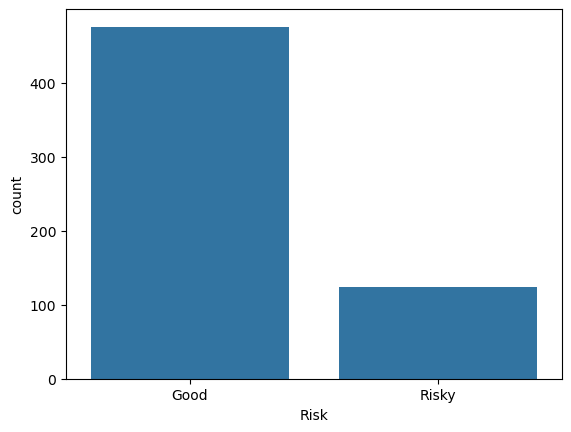

In [9]:
# Expolratory Data Analysis

# Risk distribution
sns.countplot(x='Risk', data=df)
plt.show()

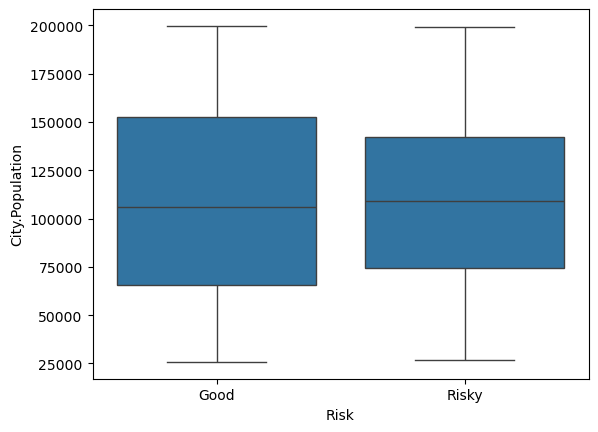

In [10]:
# City population vs Risk
sns.boxplot(x='Risk', y='City.Population', data=df)
plt.show()

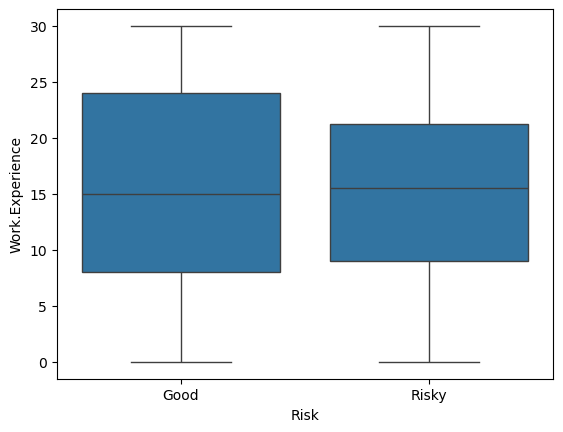

In [11]:
# Work Experience vs Risk
sns.boxplot(x='Risk', y='Work.Experience', data=df)
plt.show()

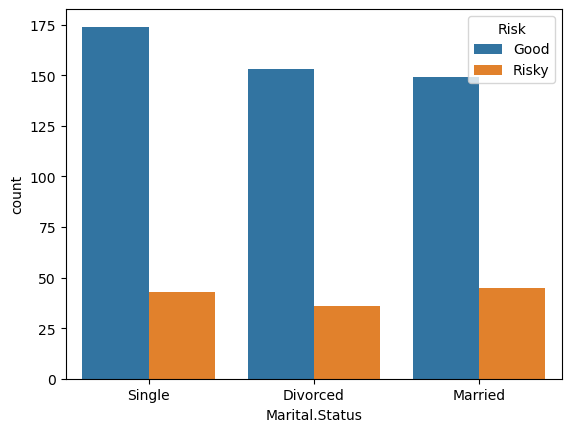

In [12]:
# Marital Status vs Risk
sns.countplot(x='Marital.Status', hue='Risk', data=df)
plt.show()

EDA helps identify patterns between demographic variables and risk classification.

Work experience and marital status may influence risk behavior.

In [13]:
# Drop Original Taxable Income
df.drop('Taxable.Income', axis=1, inplace=True)

In [14]:
# Define X and y
X = df.drop('Risk', axis=1)
y = df['Risk']

In [15]:
# Encode Categorical Variables
X = pd.get_dummies(X, drop_first=True)

In [16]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [17]:
# Building the model
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

Random Forest improves prediction reliability by combining multiple Decision Trees.

This reduces overfitting and produces more stable classification results.

In [18]:
# Prediction
y_pred = model.predict(X_test)

In [19]:
# Evaluation
accuracy_score(y_test, y_pred)

0.7333333333333333

In [20]:
# Confusion Matrix
confusion_matrix(y_test, y_pred)

array([[88,  6],
       [26,  0]])

In [21]:
# Classification Report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        Good       0.77      0.94      0.85        94
       Risky       0.00      0.00      0.00        26

    accuracy                           0.73       120
   macro avg       0.39      0.47      0.42       120
weighted avg       0.60      0.73      0.66       120



The Random Forest model successfully classifies individuals into
Risky and Good categories.

The model captures important patterns associated with taxable income behavior.

In [22]:
# Feature Importance
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance.sort_values(by='Importance', ascending=False)

,Feature,Importance
0,City.Population,0.543116
1,Work.Experience,0.334691
2,Undergrad_YES,0.036858
5,Urban_YES,0.036427
3,Marital.Status_Married,0.026014
4,Marital.Status_Single,0.022894


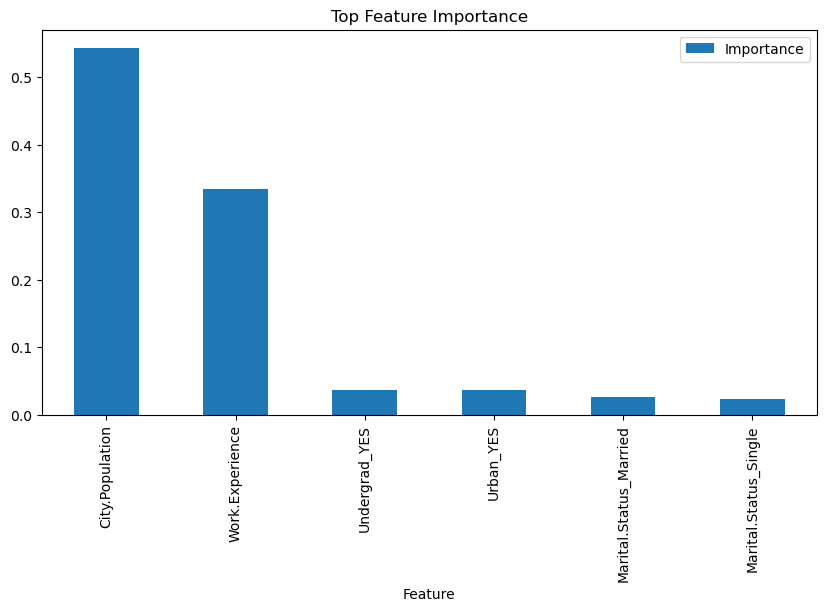

In [23]:
# Feature importance visualization
importance.sort_values(by='Importance', ascending=False).head(10).plot(
    kind='bar',
    x='Feature',
    y='Importance',
    figsize=(10,5)
)

plt.title("Top Feature Importance")
plt.show()

Feature importance analysis revealed that:

- City population significantly influences risk classification.
- Work experience impacts financial behavior and taxable income patterns.
- Educational background also contributes to identifying risky individuals.

These variables help explain demographic and behavioral risk patterns.

Random Forest is an ensemble learning algorithm that combines
multiple Decision Trees to improve prediction accuracy and reduce overfitting.

Business Insights:

1. Individuals from certain population demographics show different risk patterns.
2. Work experience appears to influence financial stability and tax behavior.
3. Educational background contributes to taxable income classification.

Business Recommendations:
- Use demographic analysis for financial risk assessment.
- Combine employment and education data for better fraud monitoring.
- Focus on high-risk segments for detailed verification processes.

Final Conclusion:

A Random Forest Classification model was successfully developed
to classify individuals into Risky and Good categories.

The model achieved an accuracy of 73.33%, demonstrating good predictive capability
for a real-world financial risk classification problem.

Feature importance analysis identified City Population,
Work Experience, and Undergrad status as the most influential factors.

Business Impact:
- Supports fraud and risk analysis
- Helps identify high-risk individuals
- Enables data-driven financial monitoring
- Improves risk assessment processes

The project demonstrates how ensemble learning techniques
can be applied to financial analytics and fraud detection.